<a href="https://colab.research.google.com/github/PranathiNagisetti/Online-Payment-Fraud-Detection/blob/main/OPFD_RandomForest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
uploaded = files.upload()


Saving PS_20174392719_1491204439457_log.csv (1).zip to PS_20174392719_1491204439457_log.csv (1).zip


In [ ]:
!unzip "PS_20174392719_1491204439457_log.csv (1).zip"


Archive:  PS_20174392719_1491204439457_log.csv (1).zip
  inflating: PS_20174392719_1491204439457_log.csv  


In [ ]:
!ls


 drive
 PS_20174392719_1491204439457_log.csv
'PS_20174392719_1491204439457_log.csv (1).zip'
 sample_data


In [ ]:
import pandas as pd

df = pd.read_csv("PS_20174392719_1491204439457_log.csv", encoding="latin1")

df.head()


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [ ]:
!pip install imbalanced-learn


In [ ]:
#imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.ensemble import RandomForestClassifier

from imblearn.over_sampling import SMOTE


In [ ]:
df.info()
df.describe()
df.isnull().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB


,0
step,0
type,0
amount,0
nameOrig,0
oldbalanceOrg,0
newbalanceOrig,0
nameDest,0
oldbalanceDest,0
newbalanceDest,0
isFraud,0


In [ ]:
df['isFraud'].value_counts()
df['isFlaggedFraud'].value_counts()

,count
isFlaggedFraud,
0,6362604
1,16


In [ ]:
#Drop irrelevant columns
df = df.drop(columns=['nameOrig', 'nameDest', 'isFlaggedFraud'])


In [ ]:
df = pd.get_dummies(df, columns=['type'], drop_first=True)


In [ ]:
#split the features
X = df.drop('isFraud', axis=1)
y = df['isFraud']


In [ ]:
print(X.shape)
print(y.shape)

(6362620, 10)
(6362620,)


In [ ]:
#Train, Test data split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)


In [ ]:
#SMOTE
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)


In [ ]:
#scale features
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_res = scaler.fit_transform(X_train_res)
X_test = scaler.transform(X_test)


In [ ]:
#Train Random Fores
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=150,
    max_depth=15,
    min_samples_split=5,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train_res, y_train_res)



RandomForestClassifier(class_weight='balanced', max_depth=15,
                       min_samples_split=5, n_estimators=150, n_jobs=-1,
                       random_state=42)

In [ ]:
import joblib

joblib.dump(X_train_res, "X_train_res.pkl")
joblib.dump(y_train_res, "y_train_res.pkl")
joblib.dump(X_test, "X_test.pkl")
joblib.dump(y_test, "y_test.pkl")


['y_test.pkl']

In [ ]:
#Predict
y_pred = rf.predict(X_test)
y_proba = rf.predict_proba(X_test)[:,1]

In [ ]:
#Evaluate

print("Classification Report:\n", classification_report(y_test, y_pred))
print("ROC AUC Score:", roc_auc_score(y_test, y_proba))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.99      1.00   1270881
           1       0.19      0.98      0.32      1643

    accuracy                           0.99   1272524
   macro avg       0.60      0.99      0.66   1272524
weighted avg       1.00      0.99      1.00   1272524

ROC AUC Score: 0.9994564694654051
Confusion Matrix:
 [[1264205    6676]
 [     31    1612]]


In [ ]:
import joblib

# Save model
joblib.dump(rf, 'random_forest_fraud_model.pkl')

# Save the scaler too
joblib.dump(scaler, 'scaler.pkl')


['scaler.pkl']

In [ ]:
rf_loaded = joblib.load('random_forest_fraud_model.pkl')
scaler_loaded = joblib.load('scaler.pkl')


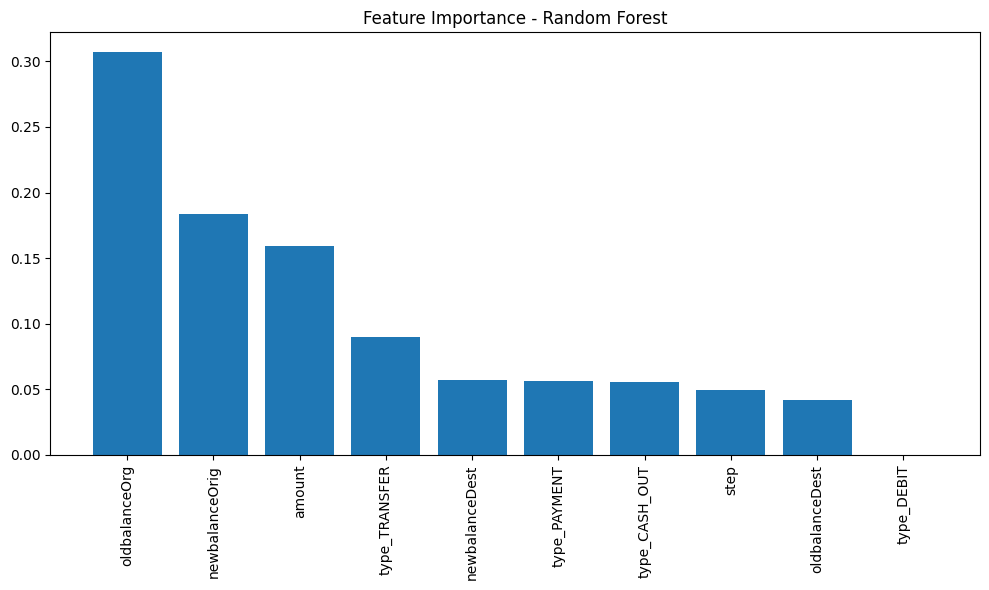

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Get feature importances and feature names
importances = rf.feature_importances_
features = X.columns

# Sort by importance
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10,6))
plt.title("Feature Importance - Random Forest")
plt.bar(range(len(importances)), importances[indices], align='center')
plt.xticks(range(len(importances)), [features[i] for i in indices], rotation=90)
plt.tight_layout()
plt.show()


In [ ]:
from google.colab import files

files.download('random_forest_fraud_model.pkl')
files.download('scaler.pkl')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
print(X.columns)


Index(['step', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest',
       'newbalanceDest', 'type_CASH_OUT', 'type_DEBIT', 'type_PAYMENT',
       'type_TRANSFER'],
      dtype='object')


In [ ]:
print(df.columns)


Index(['step', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest',
       'newbalanceDest', 'isFraud', 'type_CASH_OUT', 'type_DEBIT',
       'type_PAYMENT', 'type_TRANSFER'],
      dtype='object')
